1.Import Library

In [2]:
import pandas as pd

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

2.Load Dataset

In [3]:
df = pd.read_csv("prediksi_stroke.csv")
(df.head(5))

,ID Pasien,Jenis Kelamin,Usia,Hipertensi,Diabetes,Penyakit Jantung,Gangguan Paru-Paru,Stroke
0,79643,L,71,Ya,Tidak,Tidak,Tidak,Ya
1,11960,L,67,Tidak,Tidak,Tidak,Tidak,Ya
2,61435,P,65,Tidak,Tidak,Tidak,Tidak,Ya
3,31063,L,77,Tidak,Tidak,Tidak,Tidak,Ya
4,21350,P,68,Ya,Tidak,Tidak,Tidak,Ya


3.Preprocessing(Drop Missing Value dan Encoding)

In [4]:
#Cek Missing value
print(df.isnull().sum())

#Menampilkan jumlah masing-masing kelas
print("Jumlah masing-masing kelas:")
print(df["Stroke"].value_counts())

# Menghapus kolom id
df = df.drop("ID Pasien", axis=1)

ID Pasien             0
Jenis Kelamin         0
Usia                  0
Hipertensi            0
Diabetes              0
Penyakit Jantung      0
Gangguan Paru-Paru    0
Stroke                0
dtype: int64
Jumlah masing-masing kelas:
Stroke
Ya       8764
Tidak    2269
Name: count, dtype: int64


4.Encoding Kolom Kategori

In [5]:
cat_cols = df.select_dtypes(include="object").columns

encoders = {}
for col in cat_cols:
    df[col] = df[col].str.lower().str.strip()
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le
df.head(5)

,Jenis Kelamin,Usia,Hipertensi,Diabetes,Penyakit Jantung,Gangguan Paru-Paru,Stroke
0,0,71,1,0,0,0,1
1,0,67,0,0,0,0,1
2,1,65,0,0,0,0,1
3,0,77,0,0,0,0,1
4,1,68,1,0,0,0,1


5.Memisahkan Fitur dan Label

In [6]:
X, y = df.drop(columns="Stroke"), df["Stroke"]

print("Fitur (X):")
print(X.head(2))

print("\nLabel (y):")
print(y.head(2))

Fitur (X):
   Jenis Kelamin  Usia  Hipertensi  Diabetes  Penyakit Jantung  \
0              0    71           1         0                 0   
1              0    67           0         0                 0   

   Gangguan Paru-Paru  
0                   0  
1                   0  

Label (y):
0    1
1    1
Name: Stroke, dtype: int64


6.Train-test split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Jumlah data latih:", X_train.shape[0])
print("Jumlah data uji:", X_test.shape[0])

Jumlah data latih: 8826
Jumlah data uji: 2207


7.Pipeline: Scaling + SMOTE + KNN

In [8]:
pipeline = Pipeline([
    ("scaler", MinMaxScaler()),
    ("smote", SMOTE(random_state=42)),
    ("knn", KNeighborsClassifier())
])

In [9]:
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)

df_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
df_scaled.head(5)

,Jenis Kelamin,Usia,Hipertensi,Diabetes,Penyakit Jantung,Gangguan Paru-Paru
0,0.0,0.670213,0.0,0.0,0.0,0.0
1,1.0,0.691489,0.0,0.0,0.0,0.0
2,1.0,0.680851,0.0,0.0,0.0,0.0
3,0.0,0.478723,0.0,0.0,0.0,0.0
4,0.0,0.627660,0.0,0.0,0.0,0.0


In [10]:
smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X_train_scaled, y_train)

print("Distribusi sebelum SMOTE:")
print(pd.Series(y_train).value_counts())

print("\nDistribusi setelah SMOTE:")
print(pd.Series(y_smote).value_counts())

Distribusi sebelum SMOTE:
Stroke
1    7011
0    1815
Name: count, dtype: int64

Distribusi setelah SMOTE:
Stroke
1    7011
0    7011
Name: count, dtype: int64


8.Grid Search Parameter

In [32]:
param_grid = {
    "smote__sampling_strategy": [0.2, 0.25, 0.3],
    "knn__n_neighbors": [7, 9, 11, 15,17, 19, 25 ],
    "knn__weights": ["distance"],
    "knn__metric": ["manhattan", "euclidean"]
}
grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=3,
    scoring="recall",
    n_jobs=-1,
    verbose=1
)
grid.fit(X_train, y_train)
print("\nBest Parameter:", grid.best_params_)
best_model = grid.best_estimator_

Fitting 3 folds for each of 42 candidates, totalling 126 fits

Best Parameter: {'knn__metric': 'manhattan', 'knn__n_neighbors': 25, 'knn__weights': 'distance', 'smote__sampling_strategy': 0.3}


c:\Users\MSI_MODERN\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
84 fits failed out of a total of 126.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
84 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\MSI_MODERN\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\MSI_MODERN\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "c:\Users\MSI_MODERN\AppData\Local\Programs\Python\Pytho

In [36]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

hasil = []

for k in [7, 9, 11, 15,17, 19, 25 ]:

    model = Pipeline([
        ('smote', SMOTE(
            sampling_strategy=grid.best_params_['smote__sampling_strategy'],
            random_state=42
        )),
        ('scaler', MinMaxScaler()),
        ('knn', KNeighborsClassifier(
            n_neighbors=k,
            weights=grid.best_params_['knn__weights'],
            metric=grid.best_params_['knn__metric']
        ))
    ])

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    hasil.append([
        k,
        round(accuracy_score(y_test, y_pred) * 100, 2),
        round(precision_score(y_test, y_pred)* 100, 2),
        round(recall_score(y_test, y_pred)* 100, 2),
        round(f1_score(y_test, y_pred)* 100, 2),
        tn, fp, fn, tp
    ])

hasil_df = pd.DataFrame(
    hasil,
    columns=[
        "K",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "TN",
        "FP",
        "FN",
        "TP"
    ]
)

print(hasil_df)

    K  Accuracy  Precision  Recall  F1-Score  TN   FP   FN    TP
0   7     77.53      80.95   93.78     86.89  67  387  109  1644
1   9     78.07      81.00   94.58     87.26  65  389   95  1658
2  11     76.71      80.99   92.36     86.30  74  380  134  1619
3  15     79.61      80.49   98.12     88.43  37  417   33  1720
4  17     79.61      80.49   98.12     88.43  37  417   33  1720
5  19     79.61      80.49   98.12     88.43  37  417   33  1720
6  25     80.11      80.50   98.92     88.76  34  420   19  1734


9.Model KNN dengan parameter optimal

In [43]:
y_pred = best_model.predict(X_test)

print("\n-AKURASI MODEL-")
print(accuracy_score(y_test, y_pred) * 100)

print("\n-CONFUSION MATRIX-")
cm = confusion_matrix(y_test, y_pred)
print(cm)

print("\n-CLASSIFICATION REPORT-")
print(classification_report(y_test, y_pred))
from sklearn.metrics import classification_report
import pandas as pd

report = classification_report(
    y_test,
    y_pred,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

# Ubah ke persen
for col in ['precision', 'recall', 'f1-score']:
    report_df[col] = report_df[col] * 100

# Bulatkan 2 angka di belakang koma
report_df = report_df.round(2)

print(report_df)


-AKURASI MODEL-
80.06343452650657

-CONFUSION MATRIX-
[[  33  421]
 [  19 1734]]

-CLASSIFICATION REPORT-
              precision    recall  f1-score   support

           0       0.63      0.07      0.13       454
           1       0.80      0.99      0.89      1753

    accuracy                           0.80      2207
   macro avg       0.72      0.53      0.51      2207
weighted avg       0.77      0.80      0.73      2207

              precision  recall  f1-score  support
0                 63.46    7.27     13.04    454.0
1                 80.46   98.92     88.74   1753.0
accuracy          80.06   80.06     80.06      0.8
macro avg         71.96   53.09     50.89   2207.0
weighted avg      76.97   80.06     73.17   2207.0


10. Visualisasi Hasil Evaluasi Model

<Figure size 640x480 with 0 Axes>

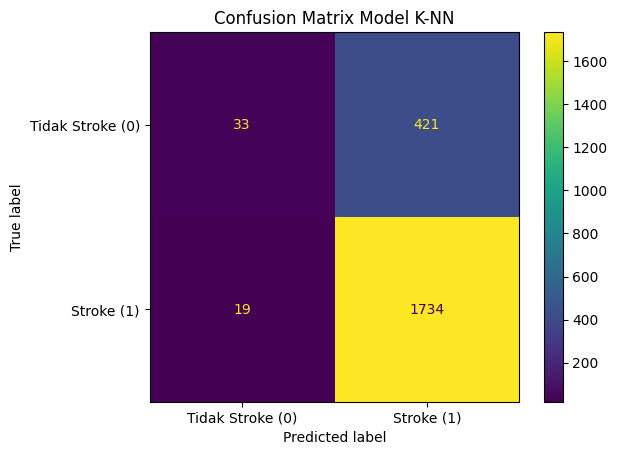

In [14]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=["Tidak Stroke (0)", "Stroke (1)"])

plt.figure()
disp.plot()
plt.title("Confusion Matrix Model K-NN")
plt.show()

11.Simpan Model 

In [15]:
import joblib

joblib.dump(best_model, "model_knn_stroke.pkl")

print("Model berhasil disimpan!")

Model berhasil disimpan!
